In [1]:
## Load all necessary libraries

import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cf
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas
from matplotlib.ticker import AutoMinorLocator
import os
import scipy
from netCDF4 import Dataset as netcdf_dataset
import matplotlib
matplotlib.matplotlib_fname()
print(plt.style.available)
matplotlib.rcParams['font.sans-serif'] = 'Arial'

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
## Load the climate model data for Hovmullers, pre-processed by ESMValTool

# This is how to load multiple files in alphabetical order
# Full set of directory lists:
CMIP5_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf/baseline/'
CMIP5_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf/endcentury/'
CMIP6_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf/baseline/'
CMIP6_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf/endcentury/'

# Initialise count and empty arrays for data
#P = np.empty(shape=(12,42,38,len(os.listdir(CMIP6_base_directory))+len(os.listdir(CMIP5_base_directory)),3))
P_all = np.empty(shape=(12,44,40,44,4))
count = 0

for dirpath, dirnames, filenames in os.walk(CMIP6_base_directory):
    dirnames.sort()
    names = sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
                               
            filenamelong = CMIP6_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P_all[:,:,:,count,0] = P1[:,53:53+44,11:11+40] # This region covers Zambia
            count = count + 1

count = 0

            
for dirpath, dirnames, filenames in os.walk(CMIP6_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP6_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P_all[:,:,:,count,3] = P1[:,53:53+44,11:11+40] # This region covers Zambia
            count = count + 1



In [3]:
## Generate date information

import datetime
from datetime import date
startt = date.fromisoformat('1980-01-01')
endt2 = date.fromisoformat('1981-01-01')

lats = thismod_ds.variables['lat'][53:53+44]
lons = thismod_ds.variables['lon'][11:11+40]
dates = pd.date_range(startt,endt2-datetime.timedelta(days=1),freq='m')

#dates

In [4]:
## Pull out r1i1p1 ensemble members from full list of models

matching = [s for s in names if "r1i1p1" in s]
count = 0

ids = np.empty([len(matching),1], dtype=int)

ids = [0]

for s in range(1,len(names)):
    s1 = names[s]
    if "r1i1p1" in s1:
        #ids[count] = s
        #count=count+1
        ids.append(s)

# Calculate the DJF mean for baseline
modsubset = np.mean(P_all[[0,1,11],:,:,:,0], axis=0)
#Calculate ensemble mean and SD for r1f1p1 members
modsubset2 = np.mean(modsubset[:,:,ids],axis=2)      
modsubset3 = np.std(modsubset[:,:,ids],axis=2)      

# Calculate the DJF mean for change
modsubseta = np.mean(P_all[[0,1,11],:,:,:,1], axis=0)
#Calculate ensemble mean and SD for r1f1p1 members
modsubset2a = np.mean(modsubseta[:,:,ids],axis=2)      
modsubset3a = np.std(modsubseta[:,:,ids],axis=2)      


In [5]:
## Load observations

obs_ids = [0,1,2,3,4,5,6,7]#[1,3,4,6,7,9,11,12,13]

thismod_ds = xr.open_dataset('/Users/ak0920/Data/Precipitation/Obs_regridded_long2.nc')
P_obs = thismod_ds["P"]
lats_obs = thismod_ds.variables['latitude']
lons_obs = thismod_ds.variables['longitude']

# Take just DJF
monids = np.arange(0,360,12) + 1008 # Adding 1008 starts the count at 1985, rather than 1901
monids2 = monids+1
monids3 = monids+11
monids4 = np.concatenate((monids,monids2,monids3))

# Calculate mean and SD
obs_DJF = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_DJF = np.std(obs_DJF[obs_ids,:,:], axis=0)
obs_mean_DJF = np.mean(obs_DJF[obs_ids,:,:], axis=0)
obs_max_DJF = np.max(obs_DJF[obs_ids,:,:], axis=0)
obs_min_DJF = np.min(obs_DJF[obs_ids,:,:], axis=0)

# Take just MAM
monids = np.arange(0,360,12) + 1008
monids1 = monids+2
monids2 = monids+3
monids3 = monids+4
monids4 = np.concatenate((monids1,monids2,monids3))

# Calculate mean and SD
obs_MAM = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_MAM = np.std(obs_MAM[obs_ids,:,:], axis=0)
obs_mean_MAM = np.mean(obs_MAM[obs_ids,:,:], axis=0)
obs_max_MAM = np.max(obs_MAM[obs_ids,:,:], axis=0)
obs_min_MAM = np.min(obs_MAM[obs_ids,:,:], axis=0)

# Take just JJA
monids = np.arange(0,360,12) + 1008
monids1 = monids+5
monids2 = monids+6
monids3 = monids+7
monids4 = np.concatenate((monids1,monids2,monids3))

# Calculate mean and SD
obs_JJA = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_JJA = np.std(obs_JJA[obs_ids,:,:], axis=0)
obs_mean_JJA = np.mean(obs_JJA[obs_ids,:,:], axis=0)
obs_max_JJA = np.max(obs_JJA[obs_ids,:,:], axis=0)
obs_min_JJA = np.min(obs_JJA[obs_ids,:,:], axis=0)

# Take just SON
monids = np.arange(0,360,12) + 1008
monids1 = monids+8
monids2 = monids+9
monids3 = monids+10
monids4 = np.concatenate((monids1,monids2,monids3))

# Calculate mean and SD
obs_SON = np.mean(P_obs[:,monids4,:,:], axis=1)
obs_std_SON = np.std(obs_SON[obs_ids,:,:], axis=0)
obs_mean_SON = np.mean(obs_SON[obs_ids,:,:], axis=0)
obs_max_SON = np.max(obs_SON[obs_ids,:,:], axis=0)
obs_min_SON = np.min(obs_SON[obs_ids,:,:], axis=0)

obs_all_mons = np.stack((np.mean(P_obs[:,monids+5,:,:], axis=1),np.mean(P_obs[:,monids+6,:,:], axis=1),np.mean(P_obs[:,monids+7,:,:], axis=1),
                              np.mean(P_obs[:,monids+8,:,:], axis=1),np.mean(P_obs[:,monids+9,:,:], axis=1),np.mean(P_obs[:,monids+10,:,:], axis=1),
                              np.mean(P_obs[:,monids+11,:,:], axis=1),np.mean(P_obs[:,monids,:,:], axis=1),np.mean(P_obs[:,monids+1,:,:], axis=1),
                              np.mean(P_obs[:,monids+2,:,:], axis=1),np.mean(P_obs[:,monids+3,:,:], axis=1),np.mean(P_obs[:,monids+4,:,:], axis=1)),axis=0)



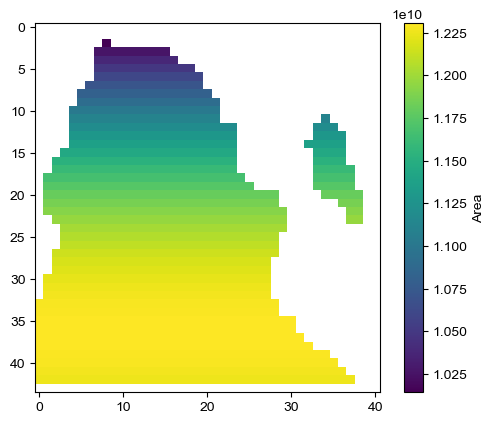

In [6]:
## Create Land-Sea Mask
# This is quite long, but it is quick and ensures a consistent LSM with the obs analysis
# Load observations
obs_ds = xr.open_dataset('/Users/ak0920/Data/Precipitation/Obs_regridded_long2.nc')
P_obs = obs_ds["P"]
lats_obs = obs_ds.variables['latitude']
lons_obs = obs_ds.variables['longitude']

# Convert data to numpy array
P_obs_arr = np.array(P_obs)

# To avoid mismatches in LSM relative to obs datasets, calculate LSM based on where obs are available
LSM1 = np.sum(np.isnan(P_obs_arr[:,1344,:,:,]),axis=0)
LSM2 = LSM1>0
LSM = np.abs(LSM2*1-1)

# Make ocean points NaN
mask_land = np.ones(LSM.shape)
for i in range(0,44):
    for j in range(0,41):        
        if LSM[i,j]==0:
            mask_land[i,j] = np.nan
            
# Calculate the global lat-long area per 1° grid cell
# Assuming the earth is a perfect sphere
def gridsize(lat1):
   #https://en.wikipedia.org/wiki/Haversine_formula
   #https://stackoverflow.com/questions/639695/how-to-convert-latitude-or-longitude-to-meters/11172685#11172685
   lon1=200
   import math
   lat2=lat1
   lon2=lon1+1

   R = 6378.137 # // Radius of earth in km
   dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
   dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
   a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
   c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
   d = R * c
   return d * 1000 #; // meters

boxlo,boxla=np.array(np.meshgrid(np.arange(-179.5,180.5,1),np.arange(-89.5,90.5,1)))
sizes=np.ones(boxlo.shape)
grid=gridsize(boxla)
grid_nc=xr.DataArray(grid,coords={'lat':boxla[:,1],'lon':boxlo[1,:]},dims=['lat','lon'])
lat_size=110567 #in m
grid_nc['m2']=grid_nc*lat_size
grid_nc=grid_nc['m2']

# Find ID of longitudes of global area grid for subset region where obs are available
lon_ids = np.arange(0,360,1)
which_id = boxlo[0,:] == np.array(lons_obs[0])
lon_id1 = lon_ids[which_id].item()
which_id = boxlo[0,:] == np.array(lons_obs[-1])
lon_id2 = lon_ids[which_id].item()+1
subsetlo = boxlo[0,lon_id1:lon_id2]

## Find ID of latitudes of global area grid for subset region
lat_ids = np.arange(0,180,1)
which_id = boxla[:,0] == np.array(lats_obs[0])
lat_id1 = lat_ids[which_id].item()
which_id = boxla[:,0] == np.array(lats_obs[-1])
lat_id2 = lat_ids[which_id].item()+1
subsetla = boxla[lat_id1:lat_id2,0]

## Create area-weighted LSM
LSM_area = grid_nc[lat_id1:lat_id2,lon_id1:lon_id2]*mask_land

# Create plot to check
plt.imshow(LSM_area)
cbar = plt.colorbar(label="Area")
plt.show()

In [7]:
## Create subsets for plotting

## Pull out r1i1p1 ensemble members from full list of models

matching = [s for s in names if "r1i1p1" in s]
count = 0

ids = np.empty([len(matching),1], dtype=int)

ids = [0]

for s in range(1,len(names)):
    s1 = names[s]
    if "r1i1p1" in s1:
        #ids[count] = s
        #count=count+1
        ids.append(s)  

# Pull out CMIP6 ensemble members from full list of models

matching6 = [s for s in names if "CMIP6" in s]
ids6 = [0]

for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6" in s1:
        ids6.append(s)

ids6

# Select CMIP5
matching5 = [s for s in names if "CMIP5" in s]
ids5a = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5" in s1:
        ids5a.append(s)

ids5 = ids5a[1:len(ids5a)]

# Select CSIRO
matchingCSIRO = [s for s in names if "CMIP5_CSIRO-Mk3-6-0_Amon_historical-rcp85" in s]
idsCSIROa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5_CSIRO-Mk3-6-0_Amon_historical-rcp85" in s1:
        idsCSIROa.append(s)

idsCSIRO = idsCSIROa[1:len(idsCSIROa)]


# Select EC-EARTH
matchingECE = [s for s in names if "CMIP5_EC-EARTH_Amon_historical-rcp85" in s]
idsECEa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5_EC-EARTH_Amon_historical-rcp85" in s1:
        idsECEa.append(s)

idsECE = idsECEa[1:len(idsECEa)]


# Select MIROC
matchingMIROC = [s for s in names if "CMIP6_MIROC6_Amon_historical-ssp585" in s]
idsMIROCa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6_MIROC6_Amon_historical-ssp585" in s1:
        idsMIROCa.append(s)

idsMIROC = idsMIROCa[1:len(idsMIROCa)]


# Select CCSM4
matchingCCSM = [s for s in names if "CMIP5_CCSM4_Amon_historical-rcp85" in s]
idsCCSMa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5_CCSM4_Amon_historical-rcp85" in s1:
        idsCCSMa.append(s)

idsCCSM = idsCCSMa[1:len(idsCCSMa)]


# Select CanESM
matchingCanESM = [s for s in names if "CMIP6_CanESM5_Amon_historical-ssp585" in s]
idsCanESMa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6_CanESM5_Amon_historical-ssp585" in s1:
        idsCanESMa.append(s)

idsCanESM = idsCanESMa[1:len(idsCanESMa)]




In [8]:
## Prepare data for Hovmuller plots of land

# Create latitude and month array for plotting x and y
lats12 = np.tile(lats, (12, 1))
mons = np.arange(1., 13.) 
mons12 = np.tile(mons, (44, 1))
mons12 = mons12.conj().T
mons1, lats1 = np.meshgrid(mons, lats)

mask_land_rep = np.repeat(mask_land[:, :, np.newaxis], 44, axis=2) # Use this if just using rif1p1
mask_land_rep = np.repeat(mask_land_rep[:, :, :, np.newaxis], 12, axis=3) # Use this if just using rif1p1
mask_land_rep = np.transpose(np.array(mask_land_rep), (3,0,1,2))
mask_land_rep = mask_land_rep[:,:,0:40,:]

# Take zonal average of baseline for all models
#P_zonal = np.nanmean(np.nanmean(P_all[:,1:43,1:39,ids,0] * mask_land_rep, axis=3), axis=2)
P_zonal = np.nanmean(np.nanmean(P_all[:,:,:,:,0] * mask_land_rep, axis=3), axis=2)

# Reshape data for plotting
P_Hov_data = P_zonal.reshape((len(mons), len(lats)))
P_Hov_data_rotated = P_Hov_data.conj().T
P_Hov_plot = np.hstack((P_Hov_data_rotated[:,5:12],P_Hov_data_rotated[:,0:5]))

# Take zonal average of change for all models
P_zonal_change = np.nanmean(np.nanmean(P_all[:,:,:,:,3] * mask_land_rep, axis=3), axis=2)

# Reshape data for plotting
P_Hov_data_change = P_zonal_change.reshape((len(mons), len(lats)))
P_Hov_data_rotated_change = P_Hov_data_change.conj().T
P_Hov_plot_change = np.hstack((P_Hov_data_rotated_change[:,5:12],P_Hov_data_rotated_change[:,0:5]))

# Agreement on direction of change
Pchangeag = np.nanmean(np.nansum((P_all[:,:,:,:,3] * mask_land_rep)>0, axis=3), axis=2)
Pchangeag2 = np.abs((Pchangeag - 22)) # This will need changed if using all members

# Reshape data for plotting
P_Hov_data_ag = Pchangeag.reshape((len(mons), len(lats)))
P_Hov_data_ag_rotated = P_Hov_data_ag.conj().T
P_Hov_plot_ag = np.hstack((P_Hov_data_ag_rotated[:,5:12],P_Hov_data_ag_rotated[:,0:5]))


/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_11346/3640638082.py:17: RuntimeWarning: Mean of empty slice
  P_zonal = np.nanmean(np.nanmean(P_all[:,:,:,:,0] * mask_land_rep, axis=3), axis=2)
/var/folders/st/j89xm2p56fdgkzlw3wf0tr600000gq/T/ipykernel_11346/3640638082.py:25: RuntimeWarning: Mean of empty slice
  P_zonal_change = np.nanmean(np.nanmean(P_all[:,:,:,:,3] * mask_land_rep, axis=3), axis=2)


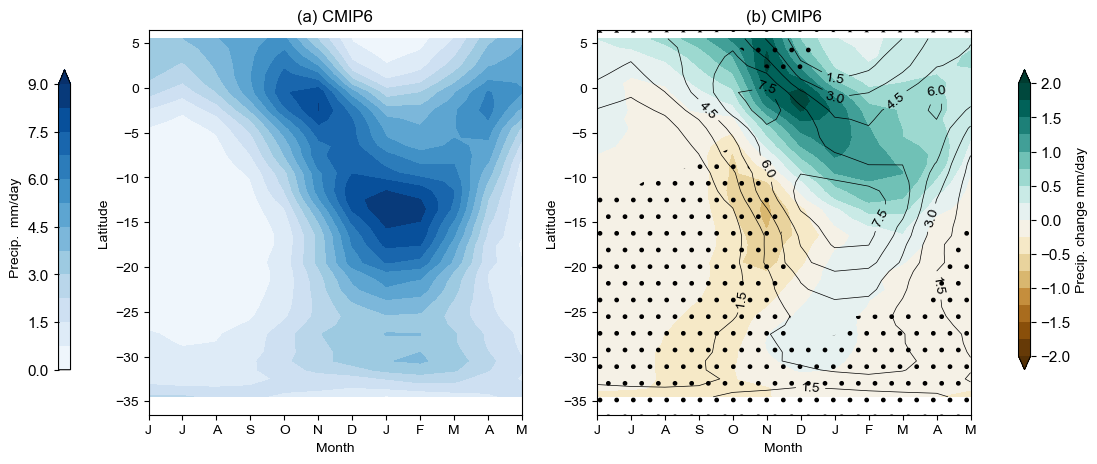

In [69]:
# Optional: Plot Hovmullers only

fig, axs = plt.subplots(1, 2, figsize=(12,5))

levels = np.linspace(0, 9, 13 )
cf1 = axs[0].contourf(mons1[:,:], lats1[:,:], P_Hov_plot,levels = levels,extend='max', cmap='Blues')
#cbar = plt.colorbar(cf, orientation='vertical', aspect=20)
#cbar.set_label('mm/day')

fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.05, 0.2, 0.01, 0.6])
cbar = fig.colorbar(cf1, cax=cbar_ax, label="Precip.  mm/day")
cbar.ax.tick_params(labelsize=11)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

axs[0].set_title('(a) CMIP6',fontname = 'arial')

axs[0].set_ylabel('Latitude')
axs[0].set_xticks(np.arange(1., 13.) ,
                  labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[0].set_xlabel('Month');
#ax.set(xlim=(1, 13))

levels1 = np.linspace(-2, 2, 17)
levels2 = np.array([0,9,35,44])

#cf = axs[1].contourf(mons1[:,:], lats1[:,:], P_Hov_plot_change,levels = levels2,extend='max')
c2 = axs[1].contourf(mons1[:,:], lats1[:,:], P_Hov_plot_change, cmap='BrBG',
                        levels=levels1, extend="both")
c3 = axs[1].contour(mons1[:,:], lats1[:,:], P_Hov_plot, colors='black',linewidths=0.5)
axs[1].clabel(c3, c3.levels, inline=True)
axs[1].contourf(mons1[:,:], lats1[:,:], P_Hov_plot_ag, levels=levels2, colors='none',
                  hatches=['.',None, '.'])
#cbar = plt.colorbar(c2, orientation='vertical', aspect=20)
#cbar.set_label('∆ mm/day')

fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.85, 0.2, 0.01, 0.6])
cbar = fig.colorbar(c2, cax=cbar_ax, label="Precip. change mm/day")
cbar.ax.tick_params(labelsize=11)

axs[1].set_title('(b) CMIP6',fontname = 'arial')

axs[1].set_ylabel('Latitude')
axs[1].set_xticks(np.arange(1., 13.) ,
                  labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[1].set_xlabel('Month');


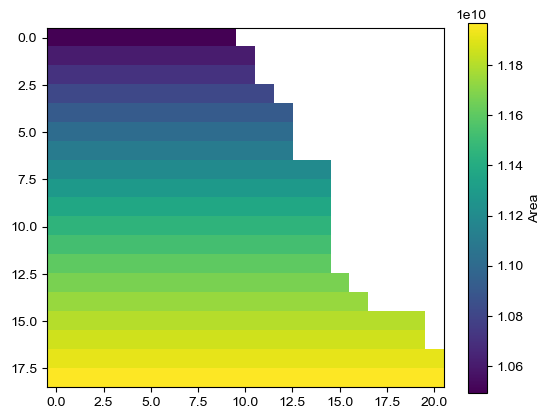

In [9]:
# Define all regions for scatter plot
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

## This correctly pulls out the ids for a defined region
# Select which region to use, or this could be a loop

# Use only the large region in this case
regno = 0;

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

# Make the same plot for land points/SADC countries only -> This makes ocean points NaN
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
# For all CMIP
areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_d = np.repeat(areas2d[:, :, np.newaxis], 8, axis=2)
areas4d_d = np.repeat(areas3d_d[:, :, :, np.newaxis], 12, axis=3)
# Convert to a fractional area
areas3d_frac_d = areas3d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
areas4d_frac_d = areas4d_d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

# Area means for observations

y_obs_mons = obs_all_mons[:,obs_ids,:,0:41]
y_obs_mons_2 = np.transpose(np.array(y_obs_mons), (2,3,1,0))
y_obs_mons_plot = np.nansum(np.nansum(y_obs_mons_2[lat_id1:lat_id2,lon_id1:lon_id2,:] * areas4d_frac_d, axis=1), axis=0)


# Create plot to check
plt.imshow(areas2d)
cbar = plt.colorbar(label="Area")
plt.show()

In [9]:
np.nansum(areas2d)/1e6

3286529.9355300777

In [10]:
## Load all the climate model data, pre-processed by ESMValTool

# This is how to load multiple files in alphabetical order
# Full set of directory lists:
CMIP5_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf all/baseline/'
CMIP5_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf all/endcentury/'
CMIP6_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf all/baseline/'
CMIP6_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf all/endcentury/'

# Initialise count and empty arrays for data
#P = np.empty(shape=(12,42,38,len(os.listdir(CMIP6_base_directory))+len(os.listdir(CMIP5_base_directory)),3))
P = np.empty(shape=(12,44,41,94+92,2))
count = 0

for dirpath, dirnames, filenames in os.walk(CMIP6_base_directory):
    dirnames.sort()
    names = sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
                               
            filenamelong = CMIP6_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,0] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_base_directory):
    dirnames.sort()
    names = names+sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,0] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1

count = 0

            
for dirpath, dirnames, filenames in os.walk(CMIP6_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP6_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,1] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,1] = P1[:,53:53+44,11:11+41] # This region covers Zambia
            count = count + 1



In [11]:
# Calculate spatial mean for each month of the year
y_months = np.empty([186,2,12])

## Process data for t-tests: all regions and seasons
months = [5,6,7,8,9,10,11,0,1,2,3,4]
for jj in range(0,12):
    j = months[jj]
    y_months[:,:,jj] = np.nansum(np.nansum(P[j,lat_id1:lat_id2,lon_id1:lon_id2] * areas4d_frac_a, axis=1), axis=0)
    



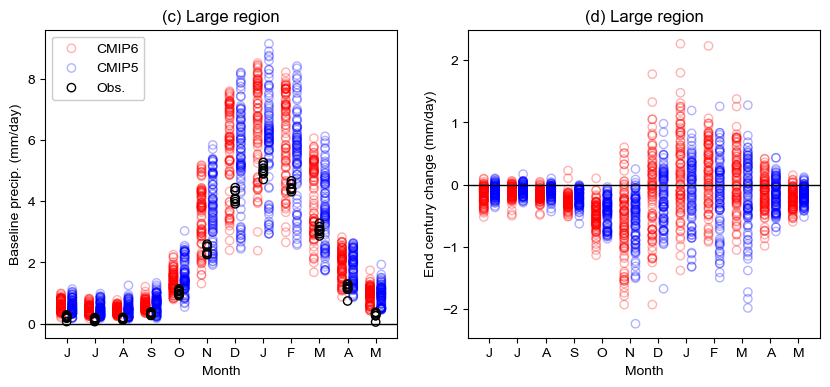

In [19]:
## Optional: Scatter plot months for selected region only

# Define a set of colours for plotting
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable

colors = cm.Spectral(np.linspace(0, 1, 11))

#fig, axs = plt.subplots(1, 3, figsize=(15,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig, axs = plt.subplots(1, 2, figsize=(10,4))
#fig, ax = plt.subplots()
# axs[0].set_facecolor((0.975, 0.975, 0.975))
axs[0].axhline(y=0, color='k', linestyle='-', linewidth=1)

# for i in range(0,len(y_months[:,0,0])):
for i in range(0,94):
    for x in range(0,12):
        if x == 0 and i == 0:
            axs[0].scatter(x+0.8, y_months[i,0,x], 
                facecolors='none', edgecolors='r',
                marker='o',alpha=0.3,label = 'CMIP6')
        else:
            axs[0].scatter(x+0.8, y_months[i,0,x], 
                facecolors='none', edgecolors='r',
                marker='o',alpha=0.3)
        
for i in range(94,186):
    for x in range(0,12): 
        if x == 0 and i == 94:
            axs[0].scatter(x+1.2, y_months[i,0,x], 
                facecolors='none', edgecolors='b',
                marker='o',alpha=0.3,label = 'CMIP5')
        else:
            axs[0].scatter(x+1.2, y_months[i,0,x], 
                facecolors='none', edgecolors='b',
                marker='o',alpha=0.3)


axs[0].set_title('(a) Large region',fontname = 'arial')

axs[0].set_ylabel('Baseline precip. (mm/day)')
axs[0].set_xticks(np.arange(1., 13.),labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[0].set_xlabel('Month');

#axs[0].axvspan(np.min(y_obs_JJA),np.max(y_obs_JJA), alpha=0.1, color='gray')
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[0,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[1,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[2,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[3,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[4,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[5,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[6,:],facecolors='none', edgecolors=(0,0,0))
axs[0].scatter(np.arange(1., 13.),y_obs_mons_plot[7,:],facecolors='none', edgecolors=(0,0,0),label = 'Obs.')

axs[0].legend(loc='upper left', ncol=1,facecolor=(1,1,1),framealpha=1)


# axs[1].set_facecolor((0.975, 0.975, 0.975))
axs[1].axhline(y=0, color='k', linestyle='-', linewidth=1)

# for i in range(0,len(y_months[:,0,0])):
for i in range(0,94):
    for x in range(0,12):
        axs[1].scatter(x+0.8, y_months[i,1,x], 
                facecolors='none', edgecolors='r',
                marker='o',alpha=0.3)
for i in range(94,186):
    for x in range(0,12): 
        axs[1].scatter(x+1.2, y_months[i,1,x], 
                facecolors='none', edgecolors='b',
                marker='o',alpha=0.3)

axs[1].set_title('(b) Large region',fontname = 'arial')

axs[1].set_ylabel('End century change (mm/day)')
axs[1].set_xticks(np.arange(1., 13.),labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[1].set_xlabel('Month');



# plt.show()
# plt.savefig('Month_scatter.pdf')



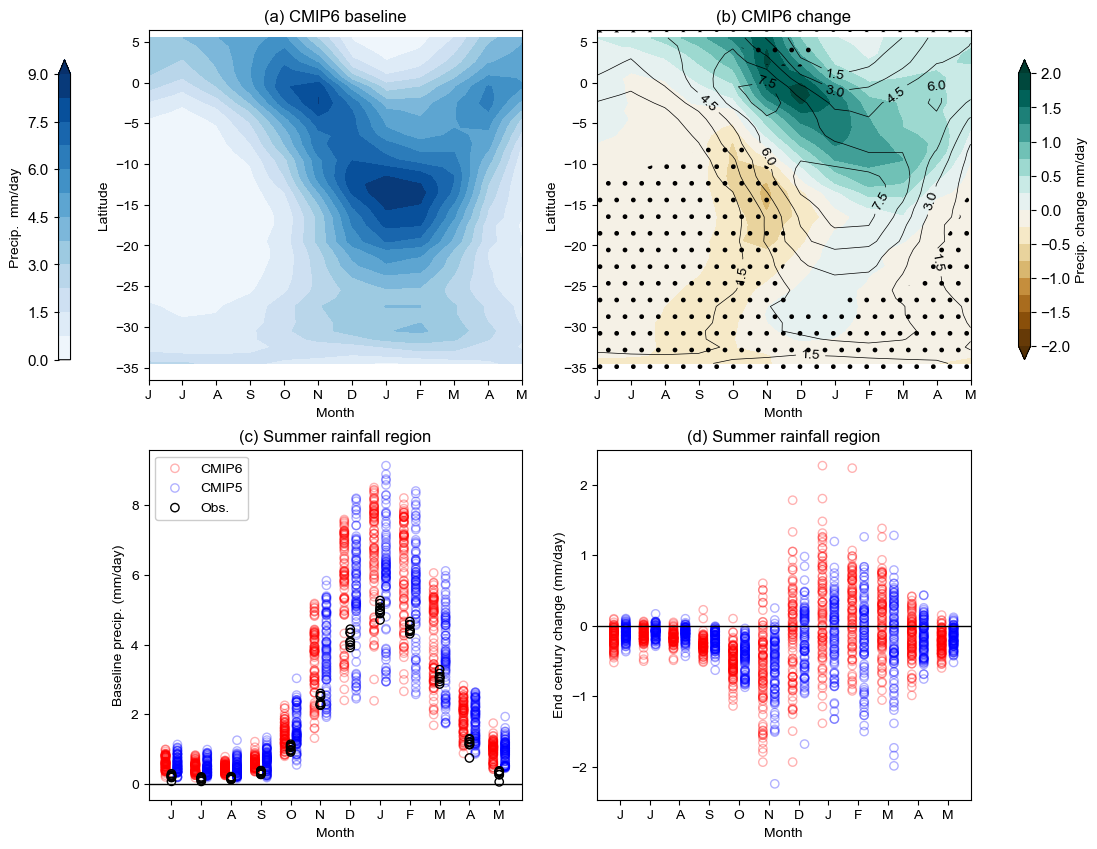

In [12]:
## Create Figure 2

fig, axs = plt.subplots(2, 2, figsize=(12,10))

levels = np.linspace(0, 9, 13 )
cf1 = axs[0,0].contourf(mons1[:,:], lats1[:,:], P_Hov_plot,levels = levels,extend='max', cmap='Blues')
#cbar = plt.colorbar(cf, orientation='vertical', aspect=20)
#cbar.set_label('mm/day')

fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.05, 0.55, 0.01, 0.3])
cbar = fig.colorbar(cf1, cax=cbar_ax, label="Precip.  mm/day")
cbar.ax.tick_params(labelsize=11)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

axs[0,0].set_title('(a) CMIP6 baseline',fontname = 'arial')

axs[0,0].set_ylabel('Latitude')
axs[0,0].set_xticks(np.arange(1., 13.) ,
                  labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[0,0].set_xlabel('Month');
#ax.set(xlim=(1, 13))

levels1 = np.linspace(-2, 2, 17)
levels2 = np.array([0,9,35,44])

#cf = axs[1].contourf(mons1[:,:], lats1[:,:], P_Hov_plot_change,levels = levels2,extend='max')
c2 = axs[0,1].contourf(mons1[:,:], lats1[:,:], P_Hov_plot_change, cmap='BrBG',
                        levels=levels1, extend="both")
c3 = axs[0,1].contour(mons1[:,:], lats1[:,:], P_Hov_plot, colors='black',linewidths=0.5)
axs[0,1].clabel(c3, c3.levels, inline=True)
axs[0,1].contourf(mons1[:,:], lats1[:,:], P_Hov_plot_ag, levels=levels2, colors='none',
                  hatches=['.',None, '.'])
#cbar = plt.colorbar(c2, orientation='vertical', aspect=20)
#cbar.set_label('∆ mm/day')

fig.subplots_adjust(right=0.81)
cbar_ax = fig.add_axes([0.85, 0.55, 0.01, 0.3])
cbar = fig.colorbar(c2, cax=cbar_ax, label="Precip. change mm/day")
cbar.ax.tick_params(labelsize=11)

axs[0,1].set_title('(b) CMIP6 change',fontname = 'arial')

axs[0,1].set_ylabel('Latitude')
axs[0,1].set_xticks(np.arange(1., 13.) ,
                  labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[0,1].set_xlabel('Month');


## Scatter

axs[1,0].axhline(y=0, color='k', linestyle='-', linewidth=1)

# for i in range(0,len(y_months[:,0,0])):
for i in range(0,94):
    for x in range(0,12):
        if x == 0 and i == 0:
            axs[1,0].scatter(x+0.8, y_months[i,0,x], 
                facecolors='none', edgecolors='r',
                marker='o',alpha=0.3,label = 'CMIP6')
        else:
            axs[1,0].scatter(x+0.8, y_months[i,0,x], 
                facecolors='none', edgecolors='r',
                marker='o',alpha=0.3)
        
for i in range(94,186):
    for x in range(0,12): 
        if x == 0 and i == 94:
            axs[1,0].scatter(x+1.2, y_months[i,0,x], 
                facecolors='none', edgecolors='b',
                marker='o',alpha=0.3,label = 'CMIP5')
        else:
            axs[1,0].scatter(x+1.2, y_months[i,0,x], 
                facecolors='none', edgecolors='b',
                marker='o',alpha=0.3)


axs[1,0].set_title('(c) Summer rainfall region',fontname = 'arial')

axs[1,0].set_ylabel('Baseline precip. (mm/day)')
axs[1,0].set_xticks(np.arange(1., 13.),labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[1,0].set_xlabel('Month');

#axs[0].axvspan(np.min(y_obs_JJA),np.max(y_obs_JJA), alpha=0.1, color='gray')
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[0,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[1,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[2,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[3,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[4,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[5,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[6,:],facecolors='none', edgecolors=(0,0,0))
axs[1,0].scatter(np.arange(1., 13.),y_obs_mons_plot[7,:],facecolors='none', edgecolors=(0,0,0),label = 'Obs.')

axs[1,0].legend(loc='upper left', ncol=1,facecolor=(1,1,1),framealpha=1)


# axs[1].set_facecolor((0.975, 0.975, 0.975))
axs[1,1].axhline(y=0, color='k', linestyle='-', linewidth=1)

# for i in range(0,len(y_months[:,0,0])):
for i in range(0,94):
    for x in range(0,12):
        axs[1,1].scatter(x+0.8, y_months[i,1,x], 
                facecolors='none', edgecolors='r',
                marker='o',alpha=0.3)
for i in range(94,186):
    for x in range(0,12): 
        axs[1,1].scatter(x+1.2, y_months[i,1,x], 
                facecolors='none', edgecolors='b',
                marker='o',alpha=0.3)

axs[1,1].set_title('(d) Summer rainfall region',fontname = 'arial')

axs[1,1].set_ylabel('End century change (mm/day)')
axs[1,1].set_xticks(np.arange(1., 13.),labels=['J', 'J', 'A', 'S', 'O', 'N', 'D','J', 'F', 'M', 'A', 'M'])
axs[1,1].set_xlabel('Month');

plt.savefig('Fig2_Hovmullers.pdf')

